# Auswertung zur Diplomarbeit

## Import der notwendigen Packages

In [1]:
from decorator import decorate
%matplotlib inline

from pathlib import Path
import contextily as cx
import geopandas as gpd
import pandas as pd
import shapely.geometry as shp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import geodatasets
import numpy as np

import diplomarbeit as da

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

import scipy.optimize as opt

import seaborn as sns

import osmnx as ox

import matplot2tikz

## Definition von Variablen und Pfaden

In [2]:
RESULTS_DIR = Path('./results')  # TODO: Make LaTeX-Picture directory for Production

plt.rc('font', family='serif', size=11)
plt.rc('text', usetex=True)

cm = 1/2.54

## Laden des Datasets

In [3]:
data=gpd.read_file(da.DATA_DIR / 'building_data.json').dropna(axis='index').reset_index(drop=True)
data

,line_name,line_number,from,to,distance,curvature,height_up,height_down,gauge,gtfs_first_stop_name,...,city,Country,ISO3166,Stadt,machine_readable,OSM-Name,Buffer_Width,region,rho_b,geometry
0,Tram 12: Amsterdam Amstelstation => Amsterdam ...,12,"Amsterdam, Amstelstation","Amsterdam, Centraal Station",7.236546,296.964916,7.462124,7.876686,1435.0,"Amsterdam, Amstelstation",...,amsterdam,Niederlande,NL,Amsterdam,amsterdam,"Amsterdam, Netherlands",60.273777,BeNeLux,0.330303,"LINESTRING (4.91789 52.34744, 4.918 52.34726, ..."
1,Tram 12: Amsterdam Centraal Station => Amsterd...,12,"Amsterdam, Centraal Station","Amsterdam, Amstelstation",7.045116,282.208086,8.090711,7.664884,1435.0,"Amsterdam, Centraal Station",...,amsterdam,Niederlande,NL,Amsterdam,amsterdam,"Amsterdam, Netherlands",60.273777,BeNeLux,0.332516,"LINESTRING (4.89929 52.37832, 4.89936 52.37825..."
2,Tram 13: Amsterdam Geuzenveld => Amsterdam Zou...,13,"Amsterdam, Lambertus Zijlplein","Amsterdam, Zoutkeetsgracht",8.317058,182.758543,7.334325,7.093855,1435.0,"Amsterdam, Lambertus Zijlplein",...,amsterdam,Niederlande,NL,Amsterdam,amsterdam,"Amsterdam, Netherlands",60.273777,BeNeLux,0.239930,"LINESTRING (4.80291 52.37728, 4.8032 52.37724,..."
3,Tram 13: Amsterdam Zoutkeetsgracht => Amsterda...,13,"Amsterdam, Zoutkeetsgracht","Amsterdam, Lambertus Zijlplein",8.299482,202.032577,7.470346,7.590835,1435.0,"Amsterdam, Zoutkeetsgracht",...,amsterdam,Niederlande,NL,Amsterdam,amsterdam,"Amsterdam, Netherlands",60.273777,BeNeLux,0.234033,"LINESTRING (4.88514 52.38808, 4.8851 52.38809,..."
4,Tram 14: Amsterdam Centraal Station => Amsterd...,14,"Amsterdam, Centraal Station","Amsterdam, Javaplein",5.048854,263.381860,10.695496,10.101302,1435.0,"Amsterdam, Centraal Station",...,amsterdam,Niederlande,NL,Amsterdam,amsterdam,"Amsterdam, Netherlands",60.273777,BeNeLux,0.322985,"LINESTRING (4.90036 52.37785, 4.90029 52.37786..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,Tram 7: Wollishoferplatz → Bahnhof Stettbach,7,"Zürich, Wollishoferplatz","Zürich, Bahnhof Stettbach",12.610090,201.312460,21.411424,22.759551,1000.0,"Zürich, Wollishoferplatz",...,zuerich,Schweiz,CH,Zürich,zuerich,"Zurich, Switzerland",83.614645,DACH,0.251457,"LINESTRING (8.53074 47.33833, 8.5308 47.33831,..."
1008,Tram 9: Heuried → Hirzenbach,9,"Zürich, Heuried","Zürich, Hirzenbach",12.081617,197.018987,19.368268,19.285498,1000.0,"Zürich, Heuried",...,zuerich,Schweiz,CH,Zürich,zuerich,"Zurich, Switzerland",83.614645,DACH,0.248528,"LINESTRING (8.50618 47.36943, 8.50607 47.36942..."
1009,Tram 9: Hirzenbach → Heuried,9,"Zürich, Hirzenbach","Zürich, Heuried",11.937945,181.472686,19.601363,19.685130,1000.0,"Zürich, Hirzenbach",...,zuerich,Schweiz,CH,Zürich,zuerich,"Zurich, Switzerland",83.614645,DACH,0.249556,"LINESTRING (8.59101 47.40316, 8.59102 47.40314..."
1010,Tram 9: Hirzenbach → Triemli,9,"Zürich, Hirzenbach","Zürich, Triemli",12.784511,178.049878,20.884647,18.616277,1000.0,"Zürich, Hirzenbach",...,zuerich,Schweiz,CH,Zürich,zuerich,"Zurich, Switzerland",83.614645,DACH,0.246638,"LINESTRING (8.59101 47.40316, 8.59102 47.40314..."


### Gruppieren der Städte

In [4]:
def weighted_average(data:pd.DataFrame, value, weight):
    val = data[value]
    wt = data[weight]
    return (val * wt).sum() / wt.sum()

In [5]:
agg_func = {'distance': ['mean', 'sum'],
            #'trip_speed': ['mean'],
            'number_trips': ['sum'],
            'curvature': ['mean', 'min','max'],
            'avg_dist': ['mean'],
            'rho_b': ['mean'],
            'machine_readable': ['count'],
            'Stadt': 'first',
            'ISO3166': 'first',
            'gauge': 'first',
           'region':'first',
            'Buffer_Width':'mean'}
df_cities_grouped = data[['Stadt', 'distance', 'trip_speed', 'number_trips', 'curvature', 'avg_dist', 'rho_b', 'gauge', 'ISO3166',
                    'machine_readable', 'region', 'Buffer_Width']].groupby(by=['ISO3166', 'Stadt']).aggregate(func=agg_func)
df_cities_grouped['trip_speeds_new']=data.groupby(['ISO3166', 'Stadt']).apply(weighted_average, 'trip_speed', 'number_trips')
df_cities_grouped.rename(columns={'machine_readable': 'Anzahl Relationen'}, inplace=True)
df_cities_grouped.rename_axis(['ISO3166', 'Stadt']).reset_index(inplace=True)
df_cities_grouped.columns = df_cities_grouped.columns.droplevel(1)
df_cities_grouped.describe()

/tmp/ipykernel_18682/67089698.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cities_grouped['trip_speeds_new']=data.groupby(['ISO3166', 'Stadt']).apply(weighted_average, 'trip_speed', 'number_trips')


,distance,distance,number_trips,curvature,curvature,curvature,avg_dist,rho_b,Anzahl Relationen,gauge,Buffer_Width,trip_speeds_new
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.00000,41.000000,41.000000
mean,11.268488,288.180609,12497.731707,164.717274,101.044335,249.320147,482.556322,0.235117,24.682927,1312.00000,85.026658,17.452347
std,3.471982,240.134393,15549.997982,57.003627,57.447033,78.196162,136.225267,0.063135,18.415264,209.72625,15.355880,3.747322
min,7.420319,32.482947,746.000000,72.170823,15.326808,121.698120,282.463094,0.110924,4.000000,900.00000,59.754241,10.136320
25%,8.849096,121.208104,2828.000000,118.080886,54.226055,185.011458,428.987807,0.201892,12.000000,1000.00000,74.045911,15.224986
50%,10.132915,224.978935,7067.000000,161.302037,92.964218,235.862161,458.925046,0.225936,21.000000,1435.00000,83.226187,17.373675
75%,11.991356,364.510698,16476.000000,191.683312,139.094957,293.297186,505.625998,0.266738,32.000000,1435.00000,94.072147,19.405199
max,22.873098,969.741123,80703.000000,335.535737,227.250354,483.888051,1078.110952,0.370176,66.000000,1524.00000,129.472409,26.829663


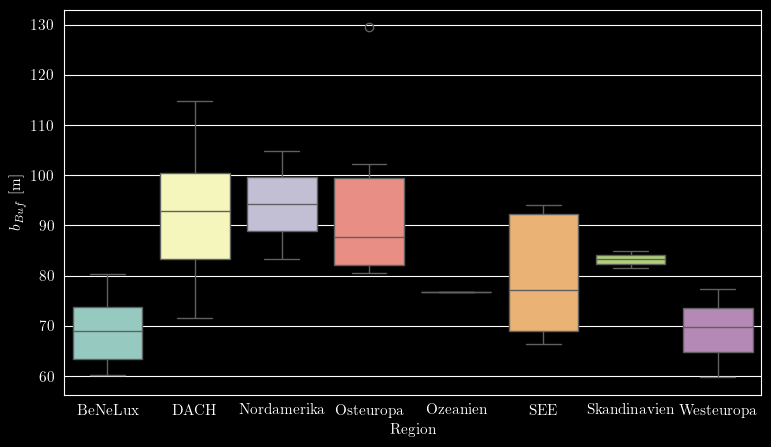

In [6]:
order=list(data['region'].unique())
order.sort()

fig, ax = plt.subplots(1,1, figsize=(9,5))
sns.boxplot(df_cities_grouped, x='region', y='Buffer_Width', hue='region', hue_order=order, order=order, ax=ax)
plt.ylabel(da.COLUMN_NAMES_TEX['Buffer_Width'])
plt.xlabel('Region')
fig.savefig(RESULTS_DIR/'Verteilungen'/'buffer_width_boxplot.png', dpi=600, bbox_inches='tight')

In [7]:
da.COLUMN_NAMES_TEX['Buffer_Width']

'$b_{Buf}$ [m]'

## Auswertung



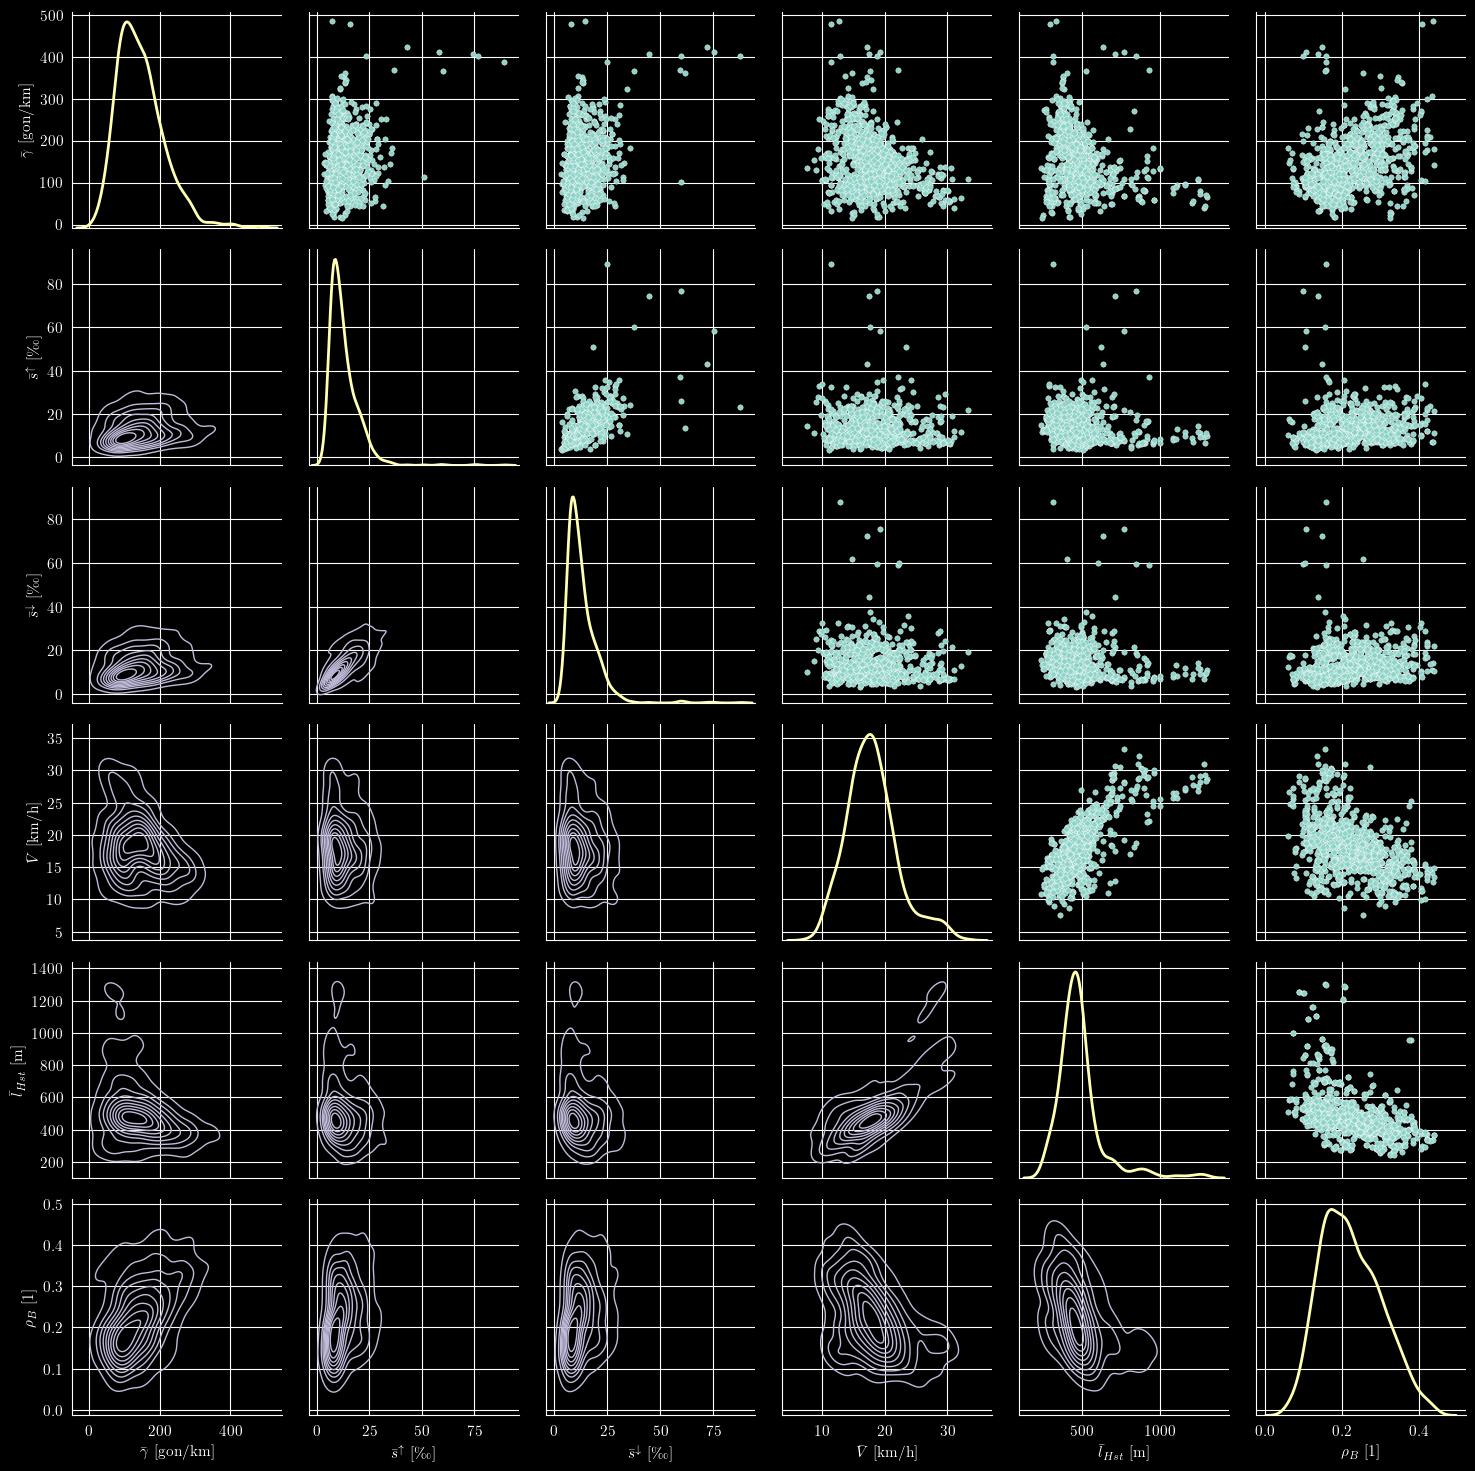

In [8]:
data_tex = data[['curvature', 'height_up', 'height_down', 'trip_speed', 'avg_dist', 'rho_b']].rename(
        columns=da.COLUMN_NAMES_TEX)

g = sns.PairGrid(data=data_tex.dropna(axis=0), diag_sharey=False)
g.map_upper(sns.scatterplot, s=15, color='C0')
g.map_diag(sns.kdeplot, lw=2, color='C1')
g.map_lower(sns.kdeplot, linewidths=1, color='C2')

### Violinplots der Parameter

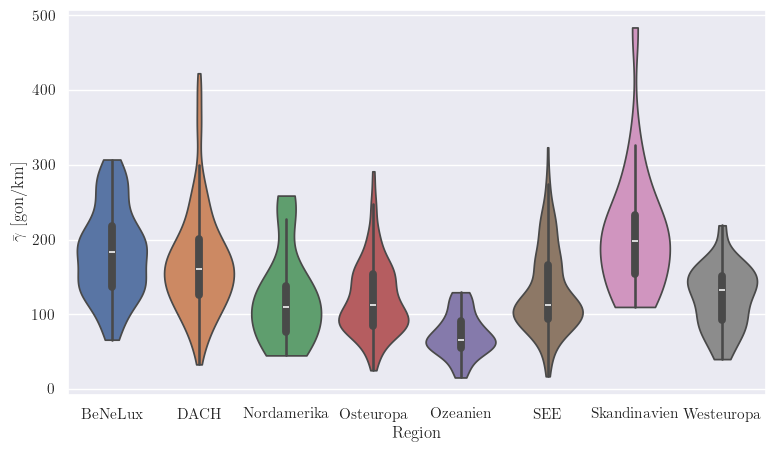

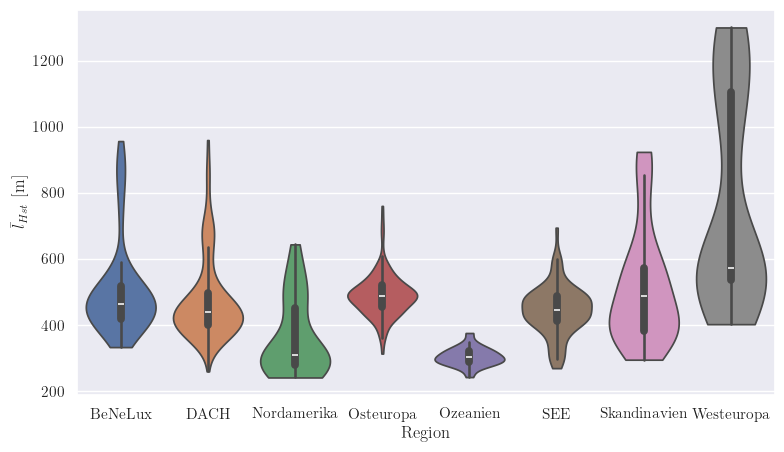

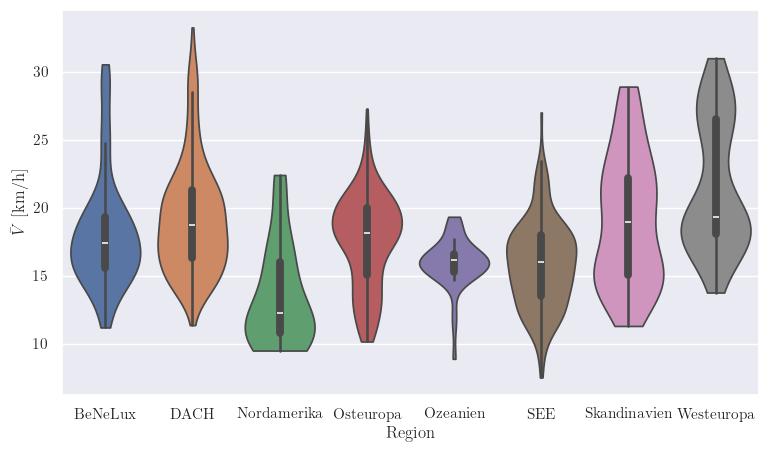

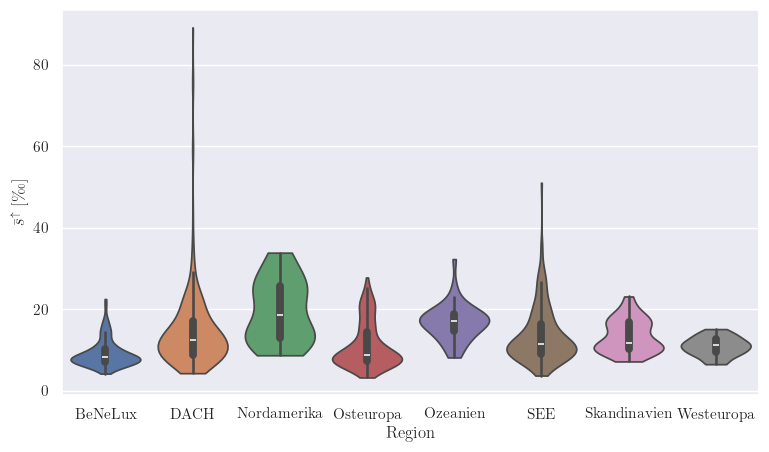

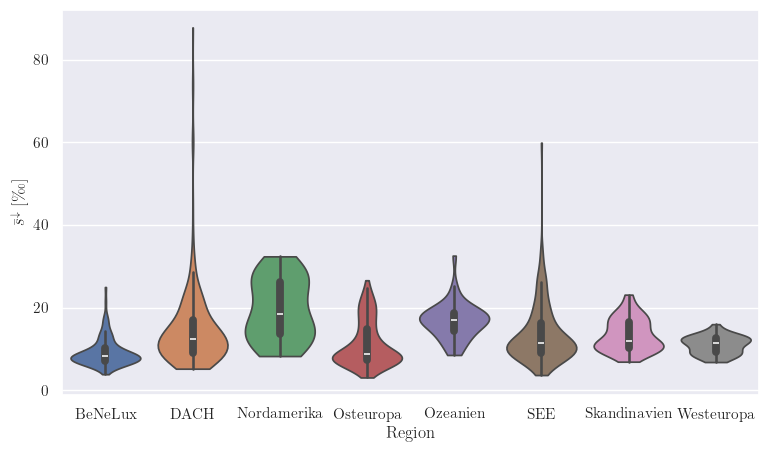

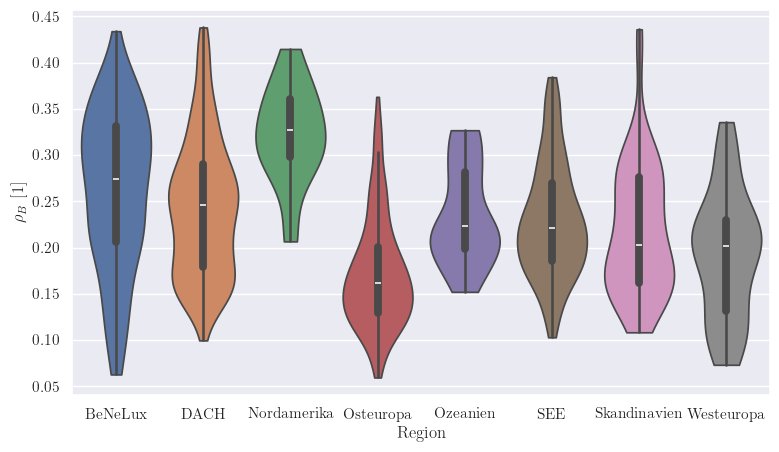

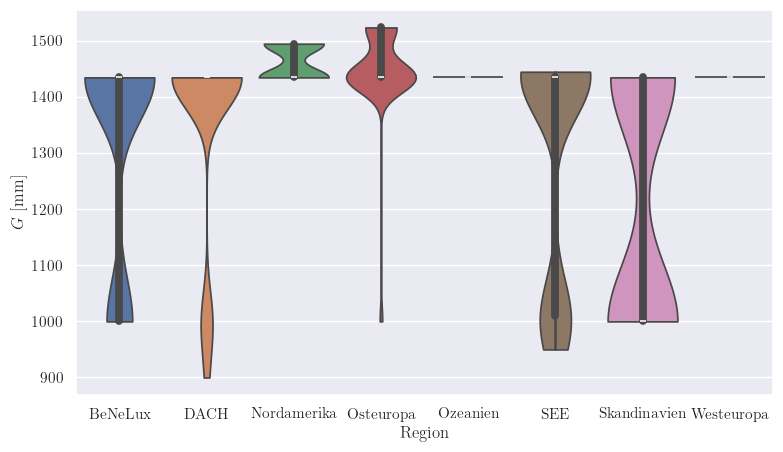

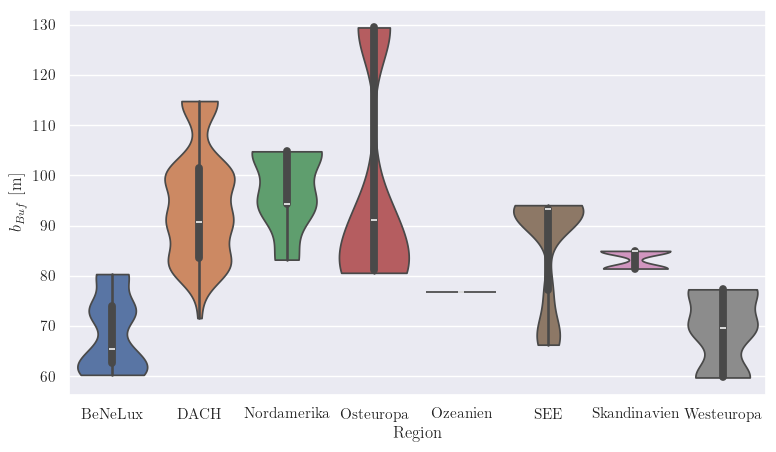

In [9]:
sns.set_theme()
plt.rc('font', family='serif', size=11)
plt.rc('text', usetex=True)



for value in da.COLUMN_NAMES_DE:
    #value='avg_dist'
    filename=value+'.png'
    filename_tex=value+'.tex'

    fig, ax = plt.subplots(1,1, figsize=(9,5))
    sns.violinplot(data=data.dropna(axis='index'), y=value, x='region', hue='region', cut=0, hue_order=order, order=order, ax=ax)
    plt.ylabel(da.COLUMN_NAMES_TEX[value])
    plt.xlabel('Region')


    plt.savefig(RESULTS_DIR / 'Verteilungen' / filename, dpi=600)

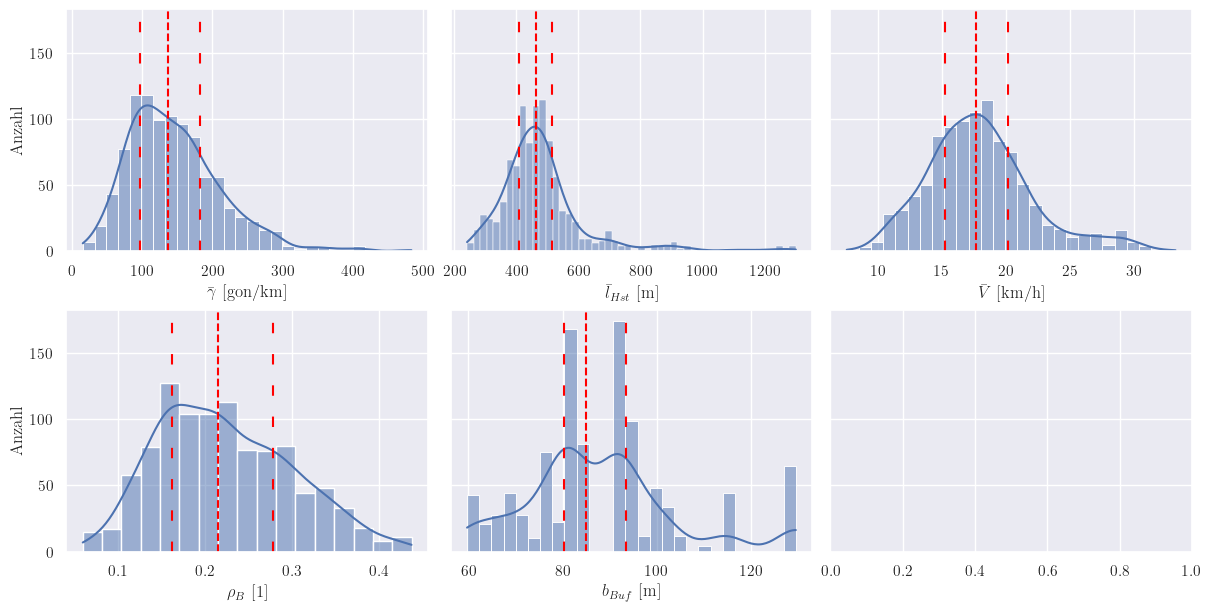

In [10]:
val_list=list(da.COLUMN_NAMES_TEX.keys())
val_list.pop(val_list.index('gauge'))
val_list.pop(val_list.index('height_up'))
val_list.pop(val_list.index('height_down'))
n = len(val_list)
ncols = int(np.ceil(np.sqrt(n)))
nrows = int(np.ceil(n / ncols))
figsize = (ncols * 4, nrows * 3)
fig, axes=plt.subplots(nrows, ncols, figsize=figsize, layout='constrained', sharey=True)

for ax, value in zip(axes.flat, val_list):
    sns.histplot(data, x=value,ax=ax, kde=True)
    ax.axvline(x=data[value].median(), color='red', ls='--')
    ax.axvline(x=data[value].quantile(0.25),
                color='red',
               ls=(0, (5, 10)))
    ax.axvline(x=data[value].quantile(0.75),
                color='red',
              ls=(0, (5, 10)))
    ax.set_xlabel(da.COLUMN_NAMES_TEX[value])
    ax.set_ylabel('Anzahl')

In [11]:
data[(data['height_up']>data['height_up'].quantile(0.95))].dropna(axis='index')[['Stadt', 'line_name','height_up']].sort_values(by='height_up', ascending=False) #& (data['region']=='Westeuropa')

,Stadt,line_name,height_up
431,Linz,50: Hauptplatz - Pöstlingberg,89.217482
338,Innsbruck,Tram STB: Innsbruck => Fulpmes,76.964968
339,Innsbruck,Tram STB: Innsbruck => Mutters,74.662570
336,Innsbruck,Tram 6: Innsbruck Mühlauer Brücke => Igls,60.177657
337,Innsbruck,Tram STB: Fulpmes => Innsbruck,58.443845
973,Zagreb,Tram 15: Mihaljevac => Gračansko Dolje,51.101259
340,Innsbruck,Tram STB: Mutters => Innsbruck,43.213692
335,Innsbruck,Tram 6: Igls Bahnhof => Innsbruck Bergisel,36.968037
802,Stuttgart,U15: Stammheim => Ruhbank (Fernsehturm),35.702875
183,Budapest,56A => Budagyöngye,35.565188


### Violinplot Höhen

In [12]:
df_height=data.dropna(axis=1)
df_height = df_height.melt(value_vars=['height_up', 'height_down'], id_vars=['line_name', 'region', 'Stadt'])
df_height['variable'] = df_height['variable'].apply(lambda x: da.COLUMN_NAMES_TEX_SHORT['height_up'] if x=='height_up' else da.COLUMN_NAMES_TEX_SHORT['height_down'])
df_height

,line_name,region,Stadt,variable,value
0,Tram 12: Amsterdam Amstelstation => Amsterdam ...,BeNeLux,Amsterdam,$\bar s^{\uparrow}$,7.462124
1,Tram 12: Amsterdam Centraal Station => Amsterd...,BeNeLux,Amsterdam,$\bar s^{\uparrow}$,8.090711
2,Tram 13: Amsterdam Geuzenveld => Amsterdam Zou...,BeNeLux,Amsterdam,$\bar s^{\uparrow}$,7.334325
3,Tram 13: Amsterdam Zoutkeetsgracht => Amsterda...,BeNeLux,Amsterdam,$\bar s^{\uparrow}$,7.470346
4,Tram 14: Amsterdam Centraal Station => Amsterd...,BeNeLux,Amsterdam,$\bar s^{\uparrow}$,10.695496
...,...,...,...,...,...
2019,Tram 7: Wollishoferplatz → Bahnhof Stettbach,DACH,Zürich,$\bar s^{\downarrow}$,22.759551
2020,Tram 9: Heuried → Hirzenbach,DACH,Zürich,$\bar s^{\downarrow}$,19.285498
2021,Tram 9: Hirzenbach → Heuried,DACH,Zürich,$\bar s^{\downarrow}$,19.685130
2022,Tram 9: Hirzenbach → Triemli,DACH,Zürich,$\bar s^{\downarrow}$,18.616277


Text(0, 0.5, '[\\textperthousand]')

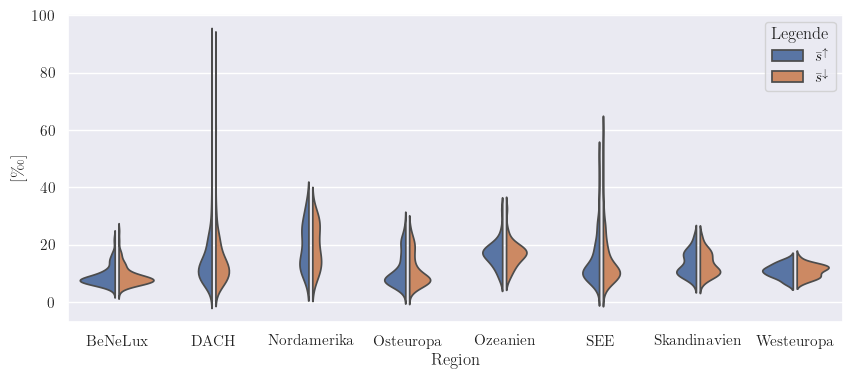

In [13]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
sns.violinplot(data= df_height,
               x='region',
               y='value',
               hue= 'variable',
               split= True,
               ax= ax,
               inner= None,
               gap= 0.1,
               #cut= 0,
               #native_scale=True,
               order=order)
plt.legend(title='Legende')
plt.xlabel('Region')
plt.ylabel(r'[\textperthousand]')

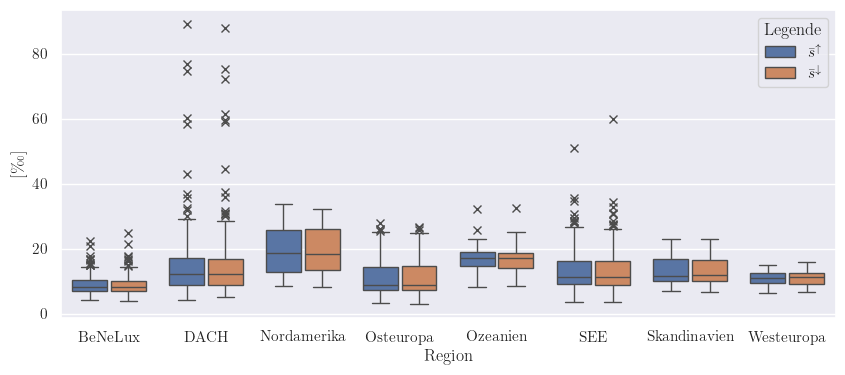

In [14]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
sns.boxplot(data= df_height,
               x='region',
               y='value',
               hue= 'variable',
               #split= True,
               ax= ax,
               #inner= None,
               gap= 0.1,
               #cut= 0,
               #native_scale=True,
               order=order,
            flierprops={"marker": "x"})
plt.legend(title='Legende')
plt.xlabel('Region')
plt.ylabel(r'[\textperthousand]')
plt.savefig(RESULTS_DIR/'Verteilungen'/'heights_boxplot.png', dpi=600, bbox_inches='tight')

### Verteilung der Spurweiten auf die Regionen

In [15]:
df_draw=df_cities_grouped.groupby(by=['region','gauge'],observed=False).aggregate(func={'Stadt':'count'})
result = df_draw.unstack('region')
result=result.droplevel(0, axis=1)

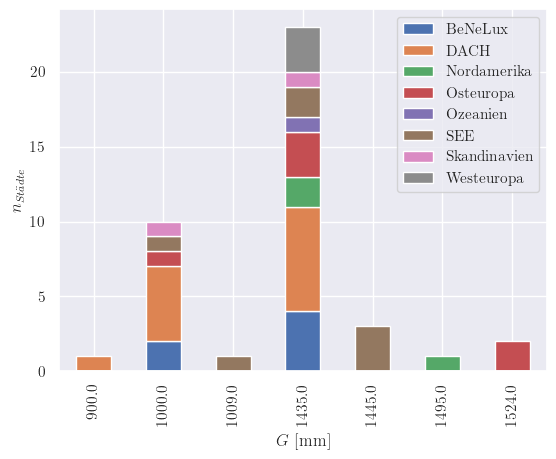

In [16]:
#g=sns.catplot(data=df_draw, x='gauge', y='Stadt', hue='region', kind='bar', hue_order=order)
#fig, ax = plt.subplots(1,1,figsize=(6.3,4.7))
g=result.plot(kind='bar', stacked=True,figsize=(6.3,4.7))
plt.legend(order)
plt.xlabel(da.COLUMN_NAMES_TEX['gauge'])
plt.ylabel(r'$n_{St\ddot{a}dte}$')
plt.savefig(RESULTS_DIR / 'Spurweiten_diagramm.png', dpi=600, bbox_inches='tight')

In [17]:
data[data['gauge']==1495]['Stadt']

819    Toronto
820    Toronto
821    Toronto
822    Toronto
823    Toronto
824    Toronto
825    Toronto
826    Toronto
827    Toronto
828    Toronto
829    Toronto
830    Toronto
Name: Stadt, dtype: object

### Lineare Regression

In [18]:
data[data['Stadt']=='Portland']

,line_name,line_number,from,to,distance,curvature,height_up,height_down,gauge,gtfs_first_stop_name,...,city,Country,ISO3166,Stadt,machine_readable,OSM-Name,Buffer_Width,region,rho_b,geometry
563,Streetcar A: Clockwise,A,Northwest Lovejoy & 9th,Northwest Lovejoy & 9th,9.896795,227.250354,26.271132,26.372175,1435.0,NW 9th & Lovejoy,...,portland,USA,US,Portland,portland,"Portland, OR, USA",83.226187,Nordamerika,0.262122,"LINESTRING (-122.68052 45.53008, -122.68048 45..."
564,Streetcar B: Counter-clockwise,B,Northwest 11th & Marshall,Northwest 11th & Marshall,10.192494,258.777770,24.037295,24.037295,1435.0,NW 11th & Marshall,...,portland,USA,US,Portland,portland,"Portland, OR, USA",83.226187,Nordamerika,0.255008,"LINESTRING (-122.68244 45.53091, -122.68244 45..."
565,Streetcar NS: Northwest 23rd & Marshall => Sou...,NS,Northwest 23rd & Marshall,South Lowell & Bond,6.239499,239.162750,25.162278,29.489549,1435.0,NW 23rd & Marshall,...,portland,USA,US,Portland,portland,"Portland, OR, USA",83.226187,Nordamerika,0.329921,"LINESTRING (-122.69867 45.53062, -122.69867 45..."
566,Streetcar NS: South Lowell & Bond => Northwest...,NS,South Lowell & Bond,Northwest 23rd & Marshall,6.414926,250.356223,33.047925,28.838991,1435.0,S Lowell & Bond,...,portland,USA,US,Portland,portland,"Portland, OR, USA",83.226187,Nordamerika,0.336571,"LINESTRING (-122.67138 45.49392, -122.6713 45...."


Text(49.852513751570434, 0.5, '$\\bar V$ [km/h]')

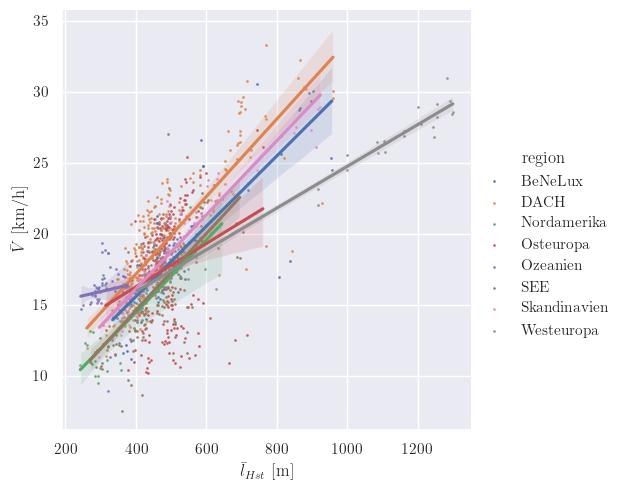

In [19]:
g=sns.lmplot(data=data.dropna(axis='index'), y='trip_speed', x='avg_dist', hue='region', hue_order=order, order=1, scatter_kws={'s':1})
#g._legend.set_title(title='Region')
plt.xlabel(da.COLUMN_NAMES_TEX['avg_dist'])
plt.ylabel(da.COLUMN_NAMES_TEX['trip_speed'])
#plt.xlim(0,1400)
#plt.ylim(0,35)


## Beschreibende Statistik Parameter

In [20]:
cols=list(da.COLUMN_NAMES_DE.keys())
data[data.columns.intersection(cols)].describe()

,curvature,height_up,height_down,gauge,trip_speed,avg_dist,Buffer_Width,rho_b
count,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000
mean,146.223275,12.964650,13.014234,1368.415020,17.972222,485.591669,88.141037,0.223775
std,66.533436,7.340290,7.481493,170.617462,4.130975,149.567188,16.418299,0.077083
min,15.326808,3.291302,3.087368,900.000000,7.547809,242.124134,59.754241,0.059673
25%,96.756185,8.192964,8.193079,1435.000000,15.212981,407.965972,80.346044,0.162665
50%,136.265705,11.189700,11.176352,1435.000000,17.659457,462.277778,84.962242,0.215789
75%,181.764309,15.681806,15.807120,1435.000000,20.165640,515.339624,93.533469,0.278289
max,483.888051,89.217482,87.834918,1524.000000,33.255673,1299.915768,129.472409,0.437954


In [21]:
weighted_average(data, 'trip_speed', 'number_trips')

np.float64(17.65123628126602)

In [22]:
df_region=data.groupby(by='region').aggregate(func=agg_func)
df_region['trip_speed']=data.groupby(by='region').apply(weighted_average, 'trip_speed', 'number_trips')
df_region.sort_values(by='trip_speed', ascending=False)
df_region['curvature']['mean'].max()

/tmp/ipykernel_18682/1532576771.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_region['trip_speed']=data.groupby(by='region').apply(weighted_average, 'trip_speed', 'number_trips')


np.float64(207.2270922346314)

<Axes: xlabel='region', ylabel='curvature'>

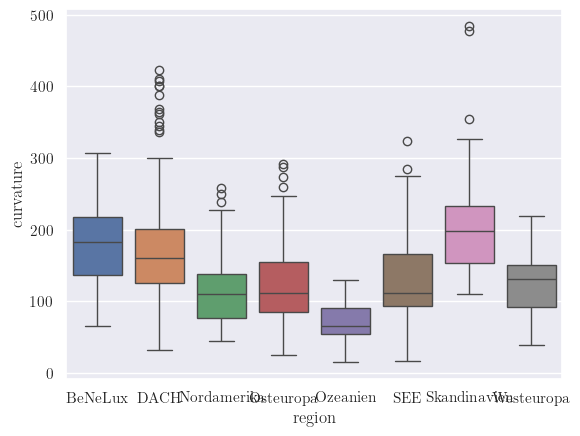

In [23]:
sns.boxplot(data, y='curvature', hue='region', x='region', hue_order=order, order=order)

In [24]:
data.sort_values('height_up', ascending=False)

,line_name,line_number,from,to,distance,curvature,height_up,height_down,gauge,gtfs_first_stop_name,...,city,Country,ISO3166,Stadt,machine_readable,OSM-Name,Buffer_Width,region,rho_b,geometry
431,50: Hauptplatz - Pöstlingberg,50,Hauptplatz,Pöstlingberg,4.102335,387.353725,89.217482,24.863889,900.0,Linz/Donau Hauptplatz,...,linz,Österreich,AT,Linz,linz,"Linz, Austria",98.379516,DACH,0.158136,"LINESTRING (14.28611 48.30636, 14.28608 48.306..."
338,Tram STB: Innsbruck => Fulpmes,STB,Innsbruck Hauptbahnhof,Fulpmes Bahnhof,20.554806,400.533843,76.964968,59.694068,1000.0,Innsbruck Hauptbahnhof D,...,innsbruck,Österreich,AT,Innsbruck,innsbruck,"Innsbruck, Austria",92.892269,DACH,0.099747,"LINESTRING (11.40024 47.2637, 11.40021 47.2635..."
339,Tram STB: Innsbruck => Mutters,STB,Innsbruck Hauptbahnhof,Mutters Kreith,13.045359,407.271250,74.662570,44.536913,1000.0,Innsbruck Hauptbahnhof D,...,innsbruck,Österreich,AT,Innsbruck,innsbruck,"Innsbruck, Austria",92.892269,DACH,0.137932,"LINESTRING (11.40024 47.2637, 11.40021 47.2635..."
336,Tram 6: Innsbruck Mühlauer Brücke => Igls,6,Innsbruck Mühlauer Brücke,Igls Bahnhof,12.845299,364.705590,60.177657,37.523455,1000.0,Innsbruck Mühlauer Brücke,...,innsbruck,Österreich,AT,Innsbruck,innsbruck,"Innsbruck, Austria",92.892269,DACH,0.155317,"LINESTRING (11.40392 47.27826, 11.4038 47.2777..."
337,Tram STB: Fulpmes => Innsbruck,STB,Fulpmes Bahnhof,Innsbruck Hauptbahnhof,21.045843,410.029418,58.443845,75.311784,1000.0,Fulpmes Bahnhof,...,innsbruck,Österreich,AT,Innsbruck,innsbruck,"Innsbruck, Austria",92.892269,DACH,0.106938,"LINESTRING (11.35242 47.15562, 11.35255 47.155..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,Tram T46: Katowice Plac Miarki → Zawodzie Zaje...,T46,Katowice Plac Miarki,Zawodzie Zajezdnia,4.032654,149.565203,4.215586,10.414978,1435.0,Katowice Plac Miarki,...,katowice,Polen,PL,Katowice,katowice,"Katowice, Poland",80.600791,Osteuropa,0.260818,"LINESTRING (19.01773 50.25441, 19.01775 50.254..."
883,Tram 31: PKP Służewiec => Metro Wierzbno,31,PKP Służewiec,Metro Wierzbno,3.235931,167.888412,4.017392,4.635452,1435.0,PKP Służewiec,...,warschau,Polen,PL,Warschau,warschau,"Warsaw, Poland",91.025085,Osteuropa,0.153739,"LINESTRING (20.98879 52.18184, 20.98875 52.181..."
789,Трамвай 5: кв. Княжево → Съдебна палата,5,кв. Княжево,Съдебна палата,7.714159,94.297318,3.759321,17.111393,1009.0,КВ. КНЯЖЕВО,...,sofia,Bulgarien,BG,Sofia,sofia,"Sofia, Bulgaria",94.072147,SEE,0.218214,"LINESTRING (23.24191 42.65891, 23.24191 42.658..."
758,Трамвай № 62: станция метро «Купчино» => Малая...,62,станция метро «Купчино»,Малая Балканская улица,3.239005,120.134082,3.704841,3.087368,1524.0,"Конечная Станция ""ст. Метро ""Купчино""",...,sankt_petersburg,Russland,RU,Sankt Petersburg,sankt_petersburg,"Saint Petersburg, Russia",129.472409,Osteuropa,0.136101,"LINESTRING (30.37803 59.83137, 30.3783 59.8311..."


## Get OSMNx Data (Entropy and Oritentations)

In [25]:
cities_df = pd.read_csv('./data/cities.csv', delimiter=';')
cities_dict=cities_df[['OSM-Name', 'RailModes']].set_index('OSM-Name').to_dict()['RailModes']

list_to_get=list(data['Stadt'].unique())
list_to_get

['Amsterdam',
 'Antwerpen',
 'Berlin',
 'Bordeaux',
 'Brandenburg a. d. Havel',
 'Brüssel',
 'Budapest',
 'Bukarest',
 'Den Haag',
 'Freiburg',
 'Gent',
 'Göteborg',
 'Graz',
 'Helsinki',
 'Innsbruck',
 'Katowice',
 'Köln',
 'Linz',
 'Lviv',
 'Lyon',
 'Mailand',
 'Manchester',
 'Melbourne',
 'München',
 'Portland',
 'Potsdam',
 'Prag',
 'Riga',
 'Rom',
 'Rotterdam',
 'San Francisco',
 'Sankt Petersburg',
 'Sofia',
 'Stuttgart',
 'Turin',
 'Toronto',
 'Ulm',
 'Warschau',
 'Wien',
 'Zagreb',
 'Zürich']

To calculate the Entropy data, use Entropy.py in the Main Directory.
The List to query in Entropy.py is the above returned List.

In [26]:
orientations=pd.read_csv(RESULTS_DIR / 'Orientations.csv')
#orientations.rename(axis='columns', inplace=True, mapper={0:'Stadt', 1:'H0_strasse', 2:'H0_tram'})
orientations['deltaphi']=abs(orientations['phi_street']-orientations['phi_tram'])
orientations.sort_values(by='deltaphi', ascending=False)

,Stadt,H0_strasse,H0_tram,phi_street,phi_tram,deltaphi
24,Portland,2.637930,3.390858,0.675440,0.167658,0.507783
17,Linz,3.544017,3.214863,0.035628,0.307377,0.271748
14,Innsbruck,3.541290,3.346137,0.038064,0.204377,0.166313
36,Ulm,3.556633,3.372336,0.024319,0.182966,0.158646
21,Manchester,3.565282,3.384425,0.016529,0.172990,0.156461
8,Den Haag,3.295176,3.476335,0.245209,0.095171,0.150038
5,Brüssel,3.542412,3.370044,0.037062,0.184850,0.147788
19,Lyon,3.501167,3.339738,0.073546,0.209563,0.136017
30,San Francisco,3.256287,3.416363,0.275645,0.146346,0.129299
34,Toronto,2.963162,3.136868,0.484905,0.365193,0.119711


## Feld für schnelle Abfragem

In [27]:
data[data.Buffer_Width == data.Buffer_Width.min()]

,line_name,line_number,from,to,distance,curvature,height_up,height_down,gauge,gtfs_first_stop_name,...,city,Country,ISO3166,Stadt,machine_readable,OSM-Name,Buffer_Width,region,rho_b,geometry
473,Manchester Metrolink: ECL OUT,ECL,Cornbrook Junction,Eccles,3.827945,168.059561,10.449470,8.098340,1435.0,Cornbrook (Manchester Metrolink),...,manchester,Vereinigtes Königreich,UK,Manchester,manchester,"Manchester, UK",59.754241,Westeuropa,0.184646,"LINESTRING (-2.29776 53.47203, -2.29769 53.472..."
474,Metrolink: Altrincham => Bury via Shudehill,Altrincham – Bury,Altrincham,Bury,30.105891,78.809294,11.260255,9.400154,1435.0,Altrincham (Manchester Metrolink),...,manchester,Vereinigtes Königreich,UK,Manchester,manchester,"Manchester, UK",59.754241,Westeuropa,0.088619,"LINESTRING (-2.3475 53.3873, -2.34724 53.38777..."
475,Metrolink: Altrincham => Piccadilly,Piccadilly - Altrincham,Altrincham,Piccadilly,14.132465,86.282069,8.774124,7.925015,1435.0,Altrincham (Manchester Metrolink),...,manchester,Vereinigtes Königreich,UK,Manchester,manchester,"Manchester, UK",59.754241,Westeuropa,0.111035,"LINESTRING (-2.3475 53.3873, -2.34724 53.38777..."
476,Metrolink: Bury => Altrincham via Shudehill,Altrincham – Bury,Bury,Altrincham,30.090048,73.266262,9.604504,11.465585,1435.0,Bury (Manchester Metrolink),...,manchester,Vereinigtes Königreich,UK,Manchester,manchester,"Manchester, UK",59.754241,Westeuropa,0.088569,"LINESTRING (-2.29743 53.59059, -2.298 53.58971..."
477,Metrolink: Bury => Piccadilly,Bury - Manchester Piccadilly,Bury,Piccadilly,17.404127,105.446368,11.778815,14.306951,1435.0,Bury (Manchester Metrolink),...,manchester,Vereinigtes Königreich,UK,Manchester,manchester,"Manchester, UK",59.754241,Westeuropa,0.099796,"LINESTRING (-2.29743 53.59059, -2.298 53.58971..."
478,Metrolink: Deansgate-Castlefield => Manchester...,Manchester Airport - Manchester Victoria,Deansgate-Castlefield,Manchester Airport,20.009098,131.987132,8.696044,6.846885,1435.0,Deansgate-Castlefield (Manchester Metrolink),...,manchester,Vereinigtes Königreich,UK,Manchester,manchester,"Manchester, UK",59.754241,Westeuropa,0.073736,"LINESTRING (-2.25031 53.47474, -2.25074 53.474..."
479,Metrolink: East Didsbury => Rochdale Town Cent...,Rochdale - East Didsbury,East Didsbury,Rochdale Town Centre,37.184854,96.256012,11.536955,9.304864,1435.0,East Didsbury (Manchester Metrolink),...,manchester,Vereinigtes Königreich,UK,Manchester,manchester,"Manchester, UK",59.754241,Westeuropa,0.123139,"LINESTRING (-2.21722 53.4121, -2.21795 53.4123..."
480,Metrolink: East Didsbury => Shaw & Crompton vi...,Shaw and Crompton - East Didsbury,East Didsbury,Shaw and Crompton,28.780741,93.794874,12.960055,8.304164,1435.0,East Didsbury (Manchester Metrolink),...,manchester,Vereinigtes Königreich,UK,Manchester,manchester,"Manchester, UK",59.754241,Westeuropa,0.131286,"LINESTRING (-2.21722 53.4121, -2.21795 53.4123..."
481,Metrolink: Manchester Airport => Deansgate-Cas...,Manchester Airport - Manchester Victoria,Manchester Airport,Deansgate-Castlefield,20.028911,135.165135,6.690329,8.537658,1435.0,Manchester Airport (Manchester Metrolink),...,manchester,Vereinigtes Königreich,UK,Manchester,manchester,"Manchester, UK",59.754241,Westeuropa,0.073374,"LINESTRING (-2.27233 53.36537, -2.27143 53.365..."
482,Metrolink: Manchester Airport => Victoria via ...,Manchester Airport - Manchester Victoria,Manchester Airport,Victoria,22.043048,162.448379,8.301937,9.662910,1435.0,Manchester Airport (Manchester Metrolink),...,manchester,Vereinigtes Königreich,UK,Manchester,manchester,"Manchester, UK",59.754241,Westeuropa,0.109837,"LINESTRING (-2.27233 53.36537, -2.27143 53.365..."


## Kombinationen aus Parametern

In [28]:
combined_parameters=[['curvature', 'height_up', 'height_down'],
                     ['curvature', 'trip_speed'],
                     ['curvature', 'rho_b'],
                     ['avg_dist', 'rho_b'],
                     ['trip_speed', 'avg_dist']]

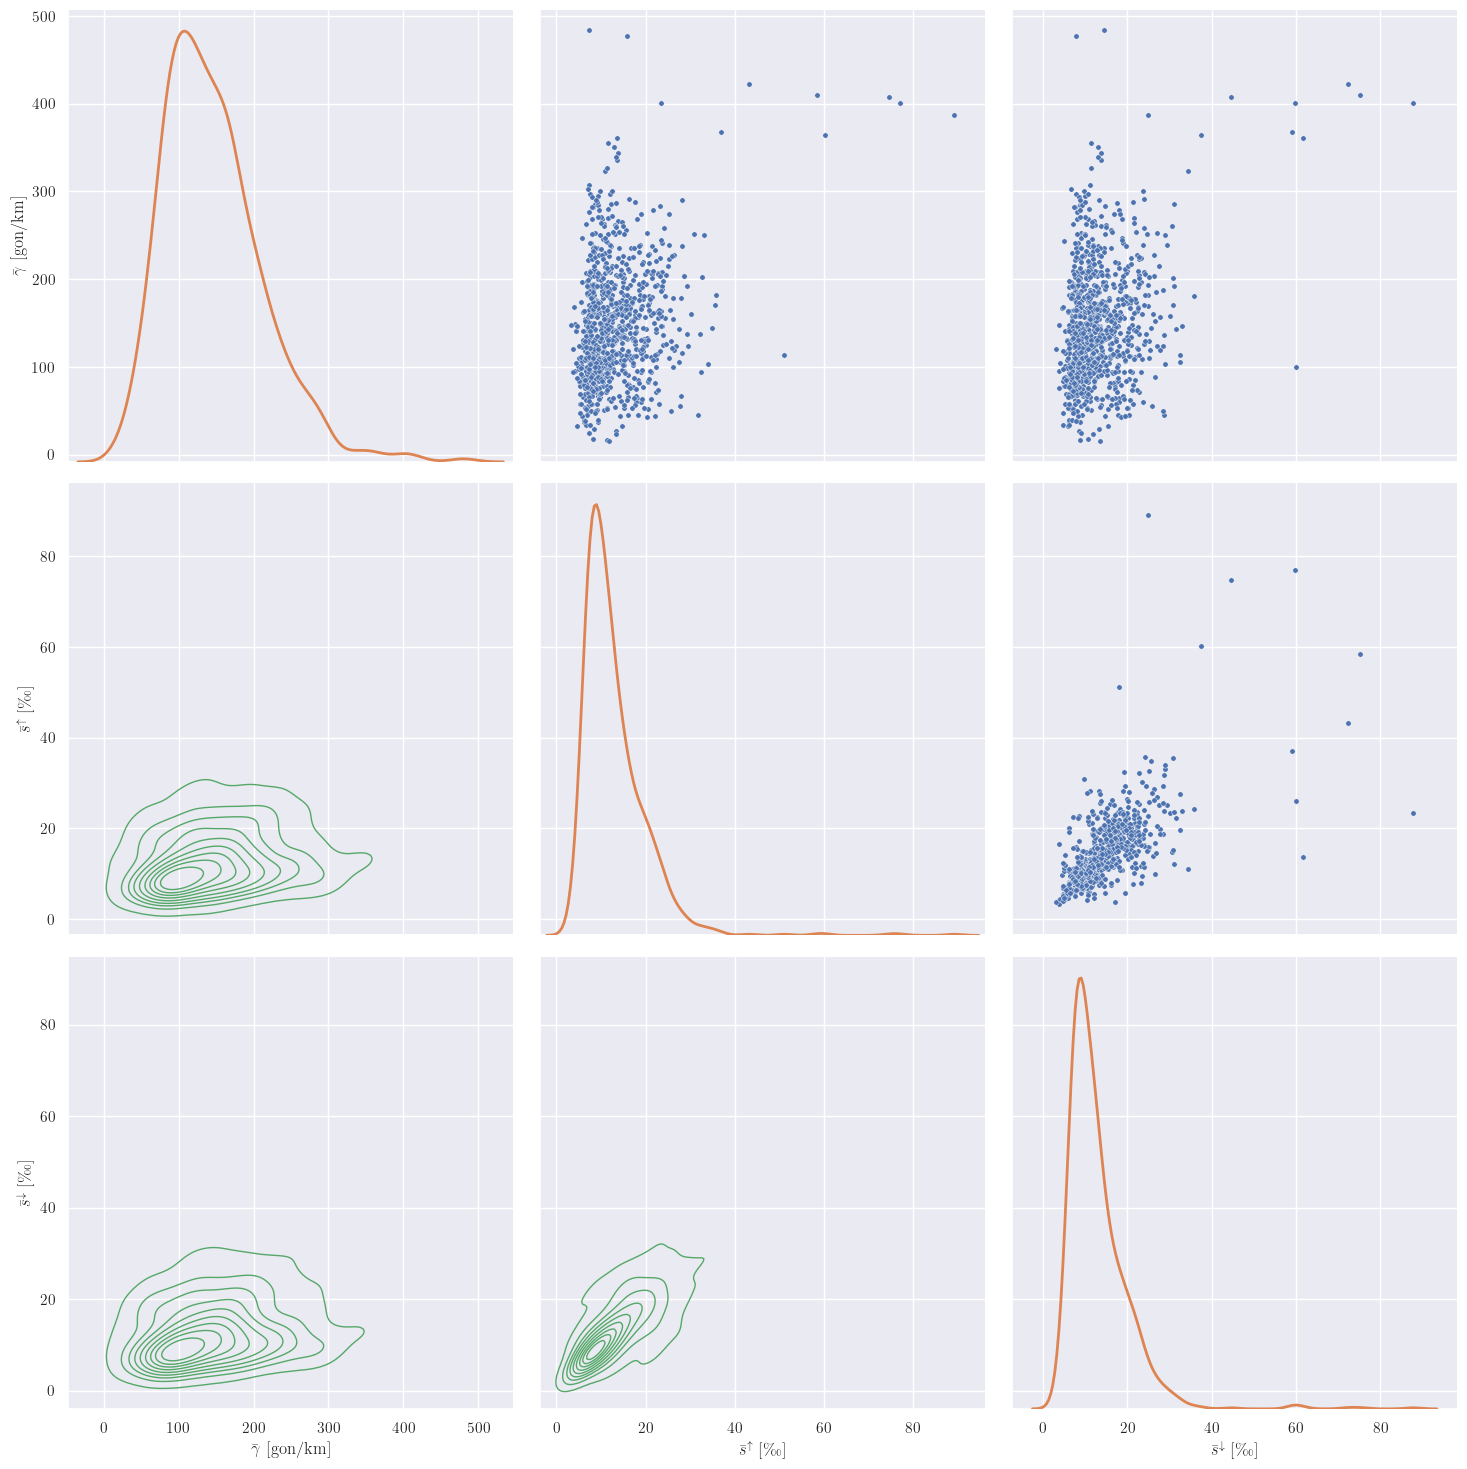

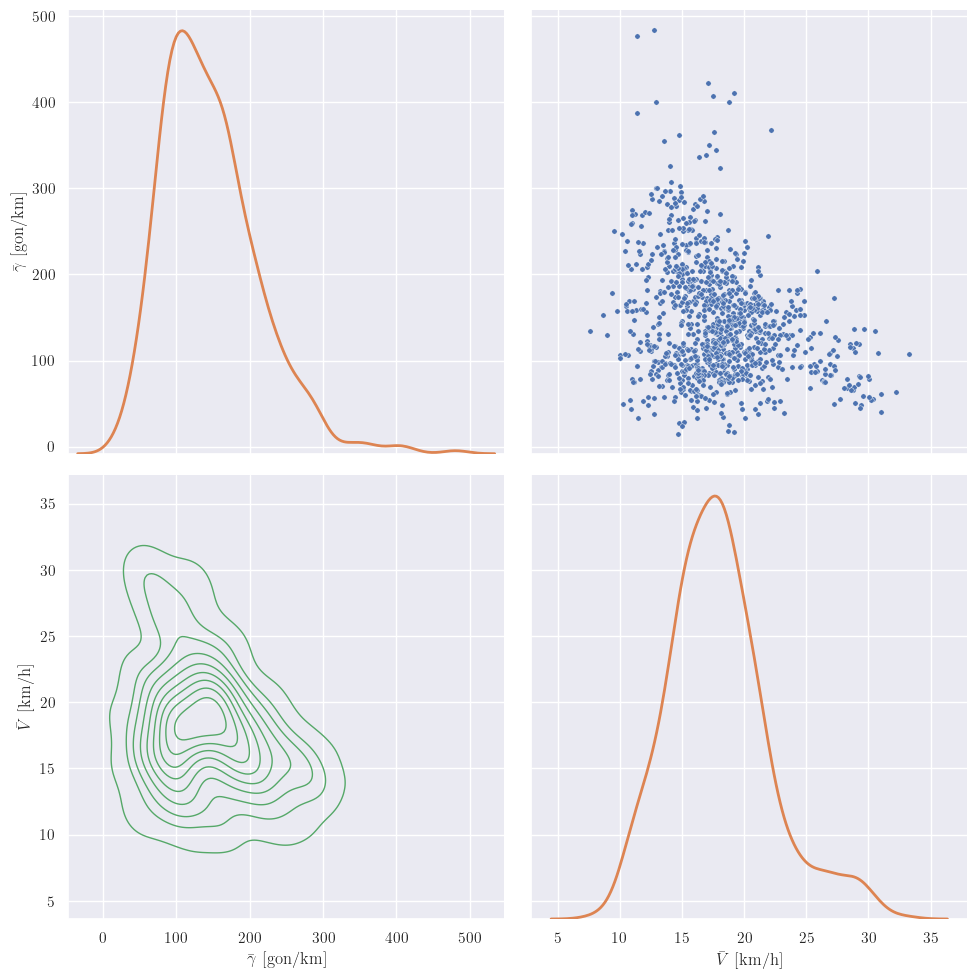

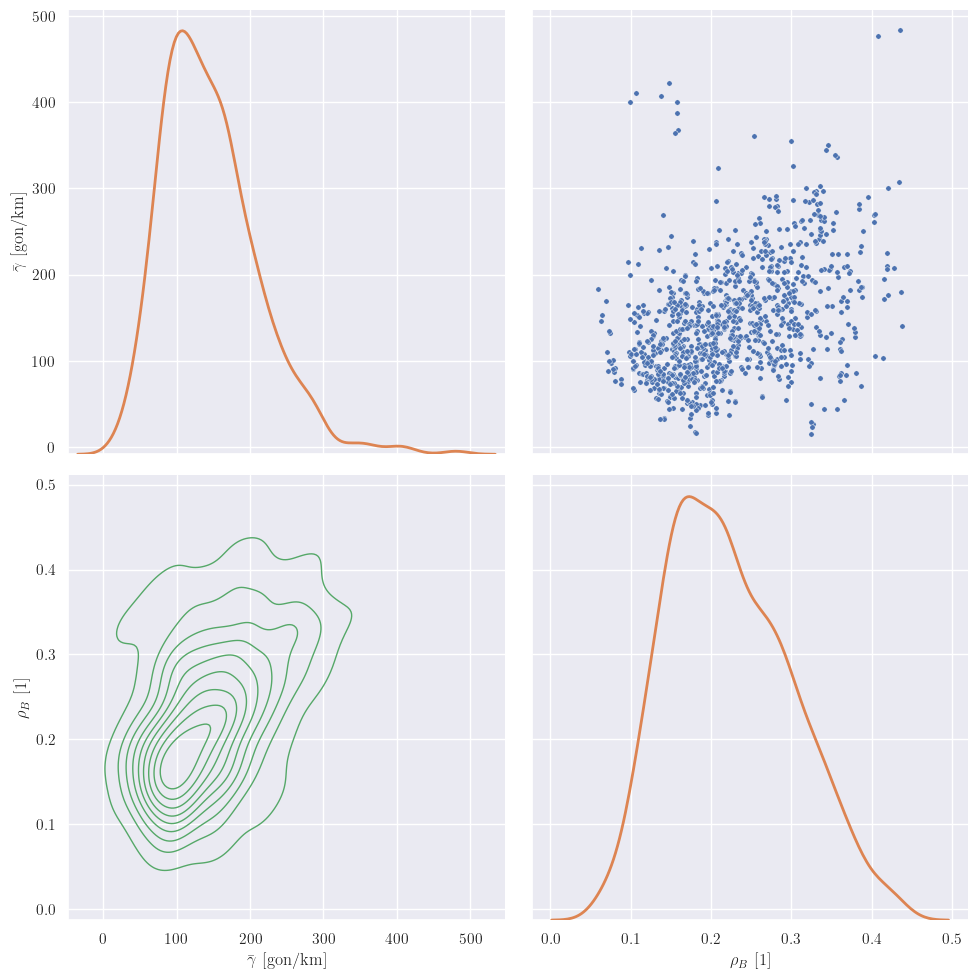

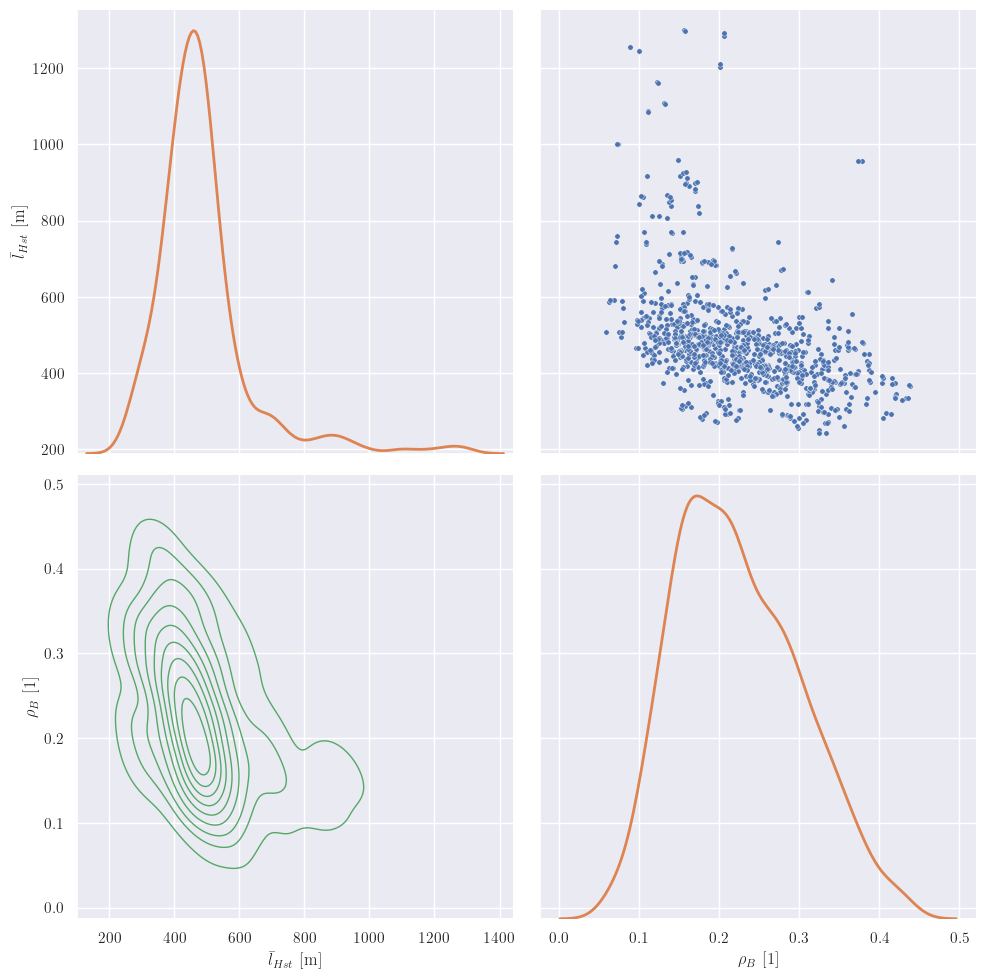

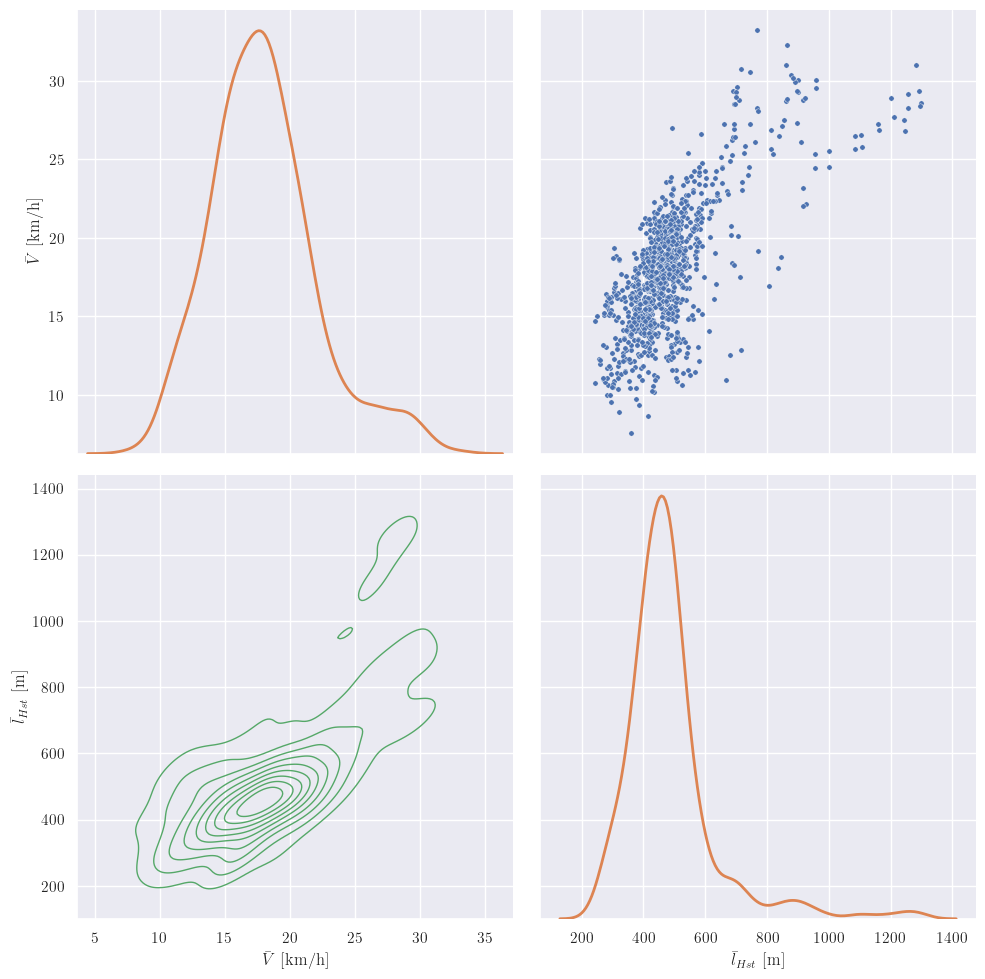

In [29]:
for combination in combined_parameters:
    data_plot=data[combination].rename(columns=da.COLUMN_NAMES_TEX)
    g = sns.PairGrid(data=data_plot, diag_sharey=False, height=5, aspect=1)
    g.map_upper(sns.scatterplot, s=15, color='C0')
    g.map_diag(sns.kdeplot, lw=2, color='C1')
    g.map_lower(sns.kdeplot, linewidths=1, color='C2')

    filename='pairplot_'+'_'.join(combination)+'.png'
    g.figure.savefig(RESULTS_DIR / 'Kombinationen'/ filename, dpi=600, bbox_inches='tight')

In [30]:
combined_parameters=[['curvature', 'height_up', 'height_down'],
                     ['curvature', 'trip_speed'],
                     ['curvature', 'rho_b'],
                     ['rho_b', 'avg_dist'],
                     ['trip_speed', 'avg_dist']]

for combination in combined_parameters:
    fig,axs=plt.subplots(1,1, figsize=(6,6))
    da.add_subplot(data,
                   x=(combination[0],da.COLUMN_NAMES_TEX[combination[0]]),
                   y=(combination[1],da.COLUMN_NAMES_TEX[combination[1]]),
                   axs=axs,
                   subaxis=0)

    filename='scatterplot_'+'_'.join(combination)+'.png'

    plt.savefig(fname=RESULTS_DIR / 'Kombinationen' / filename, bbox_inches='tight')
    plt.close()

/home/flof/Documents/Diplomarbeit/osm-horizontal-curvature/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/flof/Documents/Diplomarbeit/osm-horizontal-curvature/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/flof/Documents/Diplomarbeit/osm-horizontal-curvature/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/flof/Documents/Diplomarbeit/osm-horizontal-curvature/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/flof/Docum

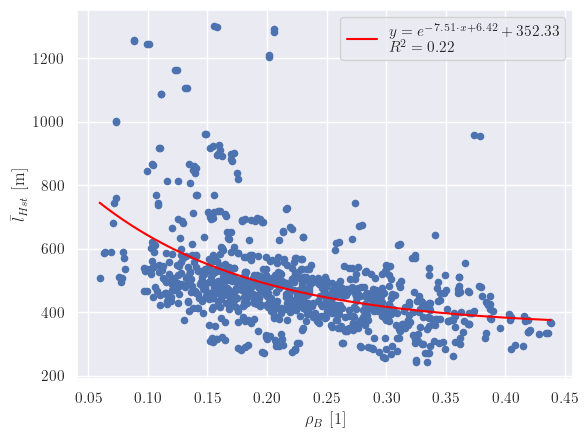

In [31]:
data['dist_log'] = np.log(data['avg_dist'])

x_ax='rho_b'
y_ax='avg_dist'

data_unabh = data[[x_ax]]
x_between = np.linspace(data_unabh.min(), data_unabh.max(), 1000)

def function(x, b, c, d):
    #y=a*x + b
    #y=a*np.log(x+c)+d
    y=np.exp(b*x+c)+d
    return y

# fit = np.polyfit(np.log(data['avg_dist']), data['rho_b'], 1)
# fx = [fit[0]*np.log(x) + fit[1] for x in x_between]

popt, pcov = opt.curve_fit(function, data[x_ax], data[y_ax], maxfev=5000)
popt = np.round(popt, 2)

residuals = data[y_ax]- function(data[x_ax], *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((data[y_ax]-np.mean(data[y_ax]))**2)
r_squared = 1 - (ss_res / ss_tot)



intercept_err = np.sqrt(pcov[0][0])
slope_err = np.sqrt(pcov[1][1])

fx = [function(x, *popt) for x in x_between]

fig, axs = plt.subplots(1,1)

data.plot.scatter(x=x_ax, y=y_ax, ax=axs)  # , marker='x', s=10, c="navy")
intercept_pre = '+' if popt[1] > 0 else ''
label_reg=(r"$y=e^{{ {0:.2f}\cdot x{4:}{1:.2f} }}+{2:.2f}$"+ '\n' +r"$R^2={3:.2f}$").format(*popt, r_squared, intercept_pre)
axs.plot(x_between[:, 0], fx, c="red", label=label_reg)
plt.legend()
plt.xlabel(da.COLUMN_NAMES_TEX[x_ax])
plt.ylabel(da.COLUMN_NAMES_TEX[y_ax])
filename='scatterplot_'+x_ax+'_'+y_ax+'.png'
plt.savefig(fname=RESULTS_DIR / 'Kombinationen' / filename, bbox_inches='tight', dpi=600)


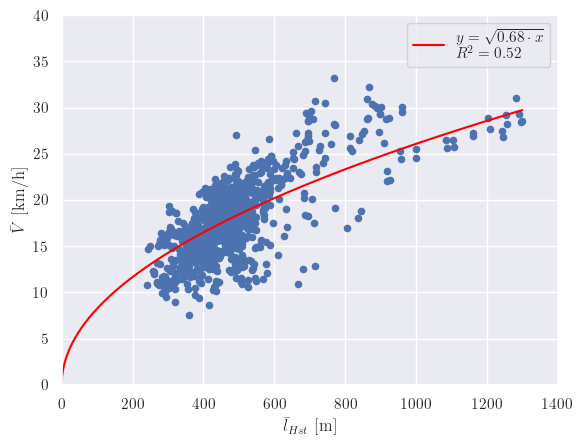

In [65]:
x_ax='avg_dist'
y_ax='trip_speed'

data_unabh = data[[x_ax]]
x_between = np.linspace(0, data_unabh.max(), 1000)

def function(x, a):
    y=np.sqrt(a*x)
    #y=a*x+d
    #y=a*np.log(x)+d
    #y=np.exp(a*x+c)+d
    return y

# fit = np.polyfit(np.log(data['avg_dist']), data['rho_b'], 1)
# fx = [fit[0]*np.log(x) + fit[1] for x in x_between]

popt, pcov = opt.curve_fit(function, data[x_ax], data[y_ax], maxfev=5000)
popt = np.round(popt, 2)

residuals = data[y_ax]- function(data[x_ax], *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((data[y_ax]-np.mean(data[y_ax]))**2)
r_squared = 1 - (ss_res / ss_tot)



#intercept_err = np.sqrt(pcov[0][0])
#slope_err = np.sqrt(pcov[1][1])

fx = [function(x, *popt) for x in x_between]

fig, axs = plt.subplots(1,1)

data.plot.scatter(x=x_ax, y=y_ax, ax=axs)  # , marker='x', s=10, c="navy")
#intercept_pre = '+' if popt[1] > 0 else ''
label_reg=(r"$y=\sqrt{{{0:.2f} \cdot x}}$"+ '\n' +r"$R^2={1:.2f}$").format(*popt, r_squared)
axs.plot(x_between[:, 0], fx, c="red", label=label_reg)
plt.legend()
plt.xlabel(da.COLUMN_NAMES_TEX[x_ax])
plt.ylabel(da.COLUMN_NAMES_TEX[y_ax])
plt.xlim((0,1400))
plt.ylim((0,40))
filename='scatterplot_'+x_ax+'_'+y_ax+'.png'
plt.savefig(fname=RESULTS_DIR / 'Kombinationen' / filename, bbox_inches='tight', dpi=600)

In [57]:
r_squared
#popt

np.float64(0.5314023439648374)